In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from Bio import Phylo, SeqIO
from Bio.Data import CodonTable
from scipy.stats import binom, chi2
from scipy.optimize import minimize
from calculate_sites import construct_dictionary

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.family"] = "serif"


In [2]:
codon_table = CodonTable.unambiguous_dna_by_name["Standard"]
codon_to_amino_acid = codon_table.forward_table

def load_data():
    tree = Phylo.read("out/ancestral_tree.tree", "newick")
    sequences = {record.id: str(record.seq) for record in SeqIO.parse("out/ancestral_sequences.fasta", "fasta")}
    return tree, sequences

def get_codon_site_counts(sequences, codon_site_counts):
    sequence_length = len(next(iter(sequences.values())))
    sequence_site_counts = {}
    for i in range(0, sequence_length, 3):
        for seq_id, sequence in sequences.items():
            codon = sequence[i:i+3]
            if seq_id not in sequence_site_counts:
                sequence_site_counts[seq_id] = {}
            sequence_site_counts[seq_id][i] = codon_site_counts.get(codon, (0, 0))
    return sequence_site_counts, sequence_length

def calculate_expected_sites(tree, sequence_site_counts, sequence_length):
    s_t, n_t = {}, {}
    for i in range(0, sequence_length, 3):
        s_t[i], n_t[i], total_branch_length = 0, 0, 0
        for clade in tree.find_clades():
            for child in clade.clades:
                branch_length = child.branch_length or 0.0
                if clade.name not in sequence_site_counts or child.name not in sequence_site_counts:
                    continue
                if i not in sequence_site_counts[clade.name] or i not in sequence_site_counts[child.name]:
                    continue
                parent_syn, parent_nonsyn = sequence_site_counts[clade.name][i]
                child_syn, child_nonsyn = sequence_site_counts[child.name][i]
                s_t[i] += branch_length * (parent_syn + child_syn) / 2
                n_t[i] += branch_length * (parent_nonsyn + child_nonsyn) / 2
                total_branch_length += branch_length
        if total_branch_length > 0:
            s_t[i] /= total_branch_length
            n_t[i] /= total_branch_length
    return s_t, n_t

def count_observed_substitutions(tree, sequences, sequence_length):
    s_c, n_c = {}, {}
    for i in range(0, sequence_length, 3):
        s_c[i], n_c[i] = 0, 0
        for clade in tree.find_clades():
            for child in clade.clades:
                if clade.name not in sequences or child.name not in sequences:
                    continue
                parent_codon = sequences[clade.name][i:i+3]
                child_codon = sequences[child.name][i:i+3]
                if parent_codon not in codon_to_amino_acid or child_codon not in codon_to_amino_acid:
                    continue
                if parent_codon == child_codon:
                    continue
                if codon_to_amino_acid[parent_codon] == codon_to_amino_acid[child_codon]:
                    s_c[i] += 1
                else:
                    n_c[i] += 1
    return s_c, n_c


In [3]:
def run_sg_method(s_t, n_t, s_c, n_c, sequence_length, significance=0.05):
    positive_sites, negative_sites = [], []
    for i in range(0, sequence_length, 3):
        if s_t[i] + n_t[i] == 0:
            continue
        prob_syn = s_t[i] / (s_t[i] + n_t[i])
        p_pos = binom.cdf(s_c[i], s_c[i] + n_c[i], prob_syn)
        if p_pos <= significance / 2:
            positive_sites.append({
                "position": i,
                "codon_pos": i // 3 + 1,
                "s_c": s_c[i],
                "n_c": n_c[i],
                "s_t": s_t[i],
                "n_t": n_t[i],
                "p_value": p_pos
            })
        prob_nonsyn = n_t[i] / (s_t[i] + n_t[i])
        p_neg = binom.cdf(n_c[i], s_c[i] + n_c[i], prob_nonsyn)
        if p_neg <= significance / 2:
            negative_sites.append({
                "position": i,
                "codon_pos": i // 3 + 1,
                "s_c": s_c[i],
                "n_c": n_c[i],
                "s_t": s_t[i],
                "n_t": n_t[i],
                "p_value": p_neg
            })
    return positive_sites, negative_sites


In [4]:
def estimate_ml_rates(s_c, n_c, s_t, n_t, codon_position):
    obs_s, obs_n = s_c[codon_position], n_c[codon_position]
    exp_s, exp_n = s_t[codon_position], n_t[codon_position]
    if exp_s + exp_n == 0 or obs_s + obs_n == 0:
        return None, None, None, None

    def neg_ll_alt(params):
        dS, dN = params
        if dS <= 0 or dN <= 0:
            return 1e10
        lambda_s, lambda_n = exp_s * dS, exp_n * dN
        if lambda_s <= 0 or lambda_n <= 0:
            return 1e10
        return -(obs_s * np.log(lambda_s) - lambda_s + obs_n * np.log(lambda_n) - lambda_n)

    def neg_ll_null(params):
        d = params[0]
        if d <= 0:
            return 1e10
        lambda_s, lambda_n = exp_s * d, exp_n * d
        if lambda_s <= 0 or lambda_n <= 0:
            return 1e10
        return -(obs_s * np.log(lambda_s) - lambda_s + obs_n * np.log(lambda_n) - lambda_n)

    initial_d = (obs_s + obs_n) / (exp_s + exp_n)
    result_alt = minimize(neg_ll_alt, x0=[initial_d, initial_d], bounds=[(1e-8, 100), (1e-8, 100)], method="L-BFGS-B")
    result_null = minimize(neg_ll_null, x0=[initial_d], bounds=[(1e-8, 100)], method="L-BFGS-B")

    if not result_alt.success or not result_null.success:
        return None, None, None, None

    lrt = max(0, 2 * (-result_alt.fun - (-result_null.fun)))
    p_value = 1 - chi2.cdf(lrt, df=1)
    return result_alt.x[0], result_alt.x[1], p_value, lrt

def run_slac_method(s_t, n_t, s_c, n_c, sequence_length, significance=0.05):
    positive_sites, negative_sites = [], []
    for i in range(0, sequence_length, 3):
        if s_t[i] + n_t[i] == 0:
            continue
        dS, dN, p_value, lrt = estimate_ml_rates(s_c, n_c, s_t, n_t, i)
        if dS is None or dN is None:
            continue
        dN_dS = dN / dS if dS > 0 else float("inf")
        if dN > dS and p_value < significance:
            positive_sites.append({
                "position": i,
                "codon_pos": i // 3 + 1,
                "dN": dN,
                "dS": dS,
                "dN_dS": dN_dS,
                "s_c": s_c[i],
                "n_c": n_c[i],
                "s_t": s_t[i],
                "n_t": n_t[i],
                "p_value": p_value,
                "lrt": lrt
            })
        elif dS > dN and p_value < significance:
            negative_sites.append({
                "position": i,
                "codon_pos": i // 3 + 1,
                "dN": dN,
                "dS": dS,
                "dN_dS": dN_dS,
                "s_c": s_c[i],
                "n_c": n_c[i],
                "s_t": s_t[i],
                "n_t": n_t[i],
                "p_value": p_value,
                "lrt": lrt
            })
    return positive_sites, negative_sites


In [5]:
tree, sequences = load_data()
codon_site_counts = construct_dictionary()
sequence_site_counts, sequence_length = get_codon_site_counts(sequences, codon_site_counts)
s_t, n_t = calculate_expected_sites(tree, sequence_site_counts, sequence_length)
s_c, n_c = count_observed_substitutions(tree, sequences, sequence_length)

sg_positive, sg_negative = run_sg_method(s_t, n_t, s_c, n_c, sequence_length)
slac_positive, slac_negative = run_slac_method(s_t, n_t, s_c, n_c, sequence_length)

print(f"SG Method: {len(sg_positive)} positive, {len(sg_negative)} negative sites")
print(f"SLAC Method: {len(slac_positive)} positive, {len(slac_negative)} negative sites")


SG Method: 0 positive, 24 negative sites
SLAC Method: 7 positive, 87 negative sites


In [6]:
sg_pos_set = set(site["position"] for site in sg_positive)
sg_neg_set = set(site["position"] for site in sg_negative)
slac_pos_set = set(site["position"] for site in slac_positive)
slac_neg_set = set(site["position"] for site in slac_negative)

pos_overlap = sg_pos_set & slac_pos_set
neg_overlap = sg_neg_set & slac_neg_set
pos_sg_only = sg_pos_set - slac_pos_set
pos_slac_only = slac_pos_set - sg_pos_set
neg_sg_only = sg_neg_set - slac_neg_set
neg_slac_only = slac_neg_set - sg_neg_set

def jaccard_similarity(set1, set2):
    if len(set1) == 0 and len(set2) == 0:
        return 1.0
    return len(set1 & set2) / len(set1 | set2)

def overlap_coefficient(set1, set2):
    if len(set1) == 0 or len(set2) == 0:
        return 0.0
    return len(set1 & set2) / min(len(set1), len(set2))

metrics = {
    "Positive Selection": {
        "SG Sites": len(sg_pos_set),
        "SLAC Sites": len(slac_pos_set),
        "Overlap": len(pos_overlap),
        "SG Only": len(pos_sg_only),
        "SLAC Only": len(pos_slac_only),
        "Jaccard Similarity": jaccard_similarity(sg_pos_set, slac_pos_set),
        "Overlap Coefficient": overlap_coefficient(sg_pos_set, slac_pos_set)
    },
    "Negative Selection": {
        "SG Sites": len(sg_neg_set),
        "SLAC Sites": len(slac_neg_set),
        "Overlap": len(neg_overlap),
        "SG Only": len(neg_sg_only),
        "SLAC Only": len(neg_slac_only),
        "Jaccard Similarity": jaccard_similarity(sg_neg_set, slac_neg_set),
        "Overlap Coefficient": overlap_coefficient(sg_neg_set, slac_neg_set)
    }
}

metrics_df = pd.DataFrame(metrics).T
print("=" * 80)
print("SIMILARITY METRICS")
print("=" * 80)
print(metrics_df.to_string())


SIMILARITY METRICS
                    SG Sites  SLAC Sites  Overlap  SG Only  SLAC Only  Jaccard Similarity  Overlap Coefficient
Positive Selection       0.0         7.0      0.0      0.0        7.0            0.000000                  0.0
Negative Selection      24.0        87.0     24.0      0.0       63.0            0.275862                  1.0


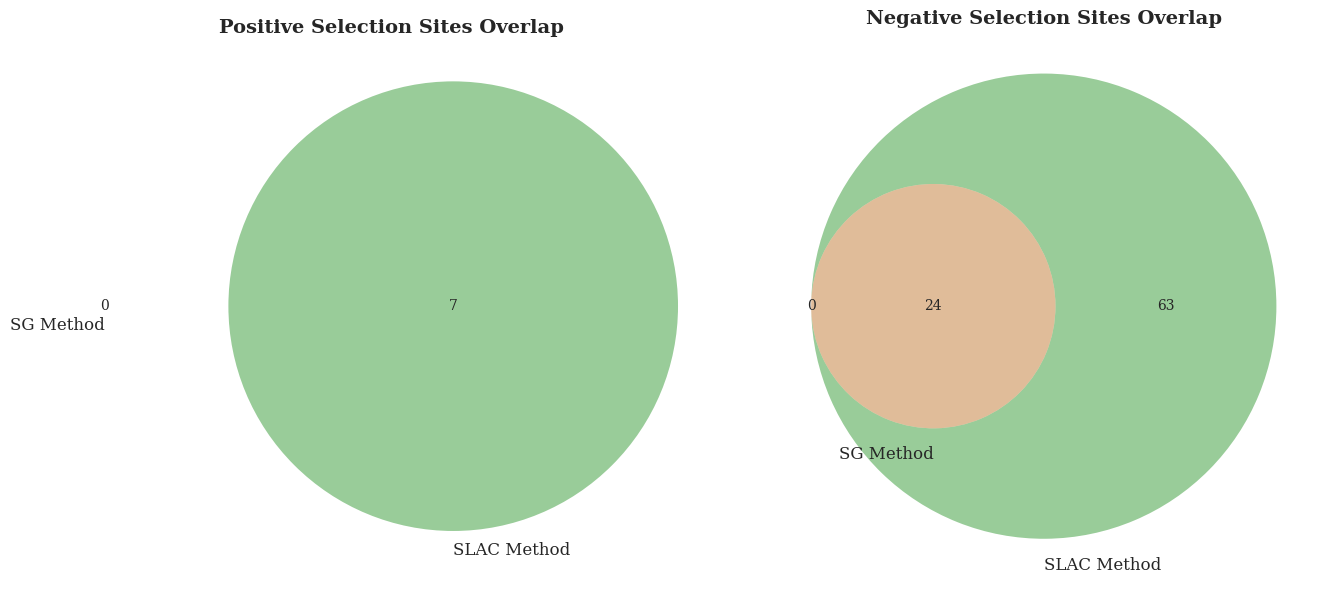

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if len(sg_pos_set) > 0 or len(slac_pos_set) > 0:
    venn2([sg_pos_set, slac_pos_set], set_labels=("SG Method", "SLAC Method"), ax=axes[0])
    axes[0].set_title("Positive Selection Sites Overlap", fontsize=14, fontweight="bold")
else:
    axes[0].text(0.5, 0.5, "No positive selection sites detected", ha="center", va="center", fontsize=12)
    axes[0].set_title("Positive Selection Sites Overlap", fontsize=14, fontweight="bold")

if len(sg_neg_set) > 0 or len(slac_neg_set) > 0:
    venn2([sg_neg_set, slac_neg_set], set_labels=("SG Method", "SLAC Method"), ax=axes[1])
    axes[1].set_title("Negative Selection Sites Overlap", fontsize=14, fontweight="bold")
else:
    axes[1].text(0.5, 0.5, "No negative selection sites detected", ha="center", va="center", fontsize=12)
    axes[1].set_title("Negative Selection Sites Overlap", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("out/venn_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


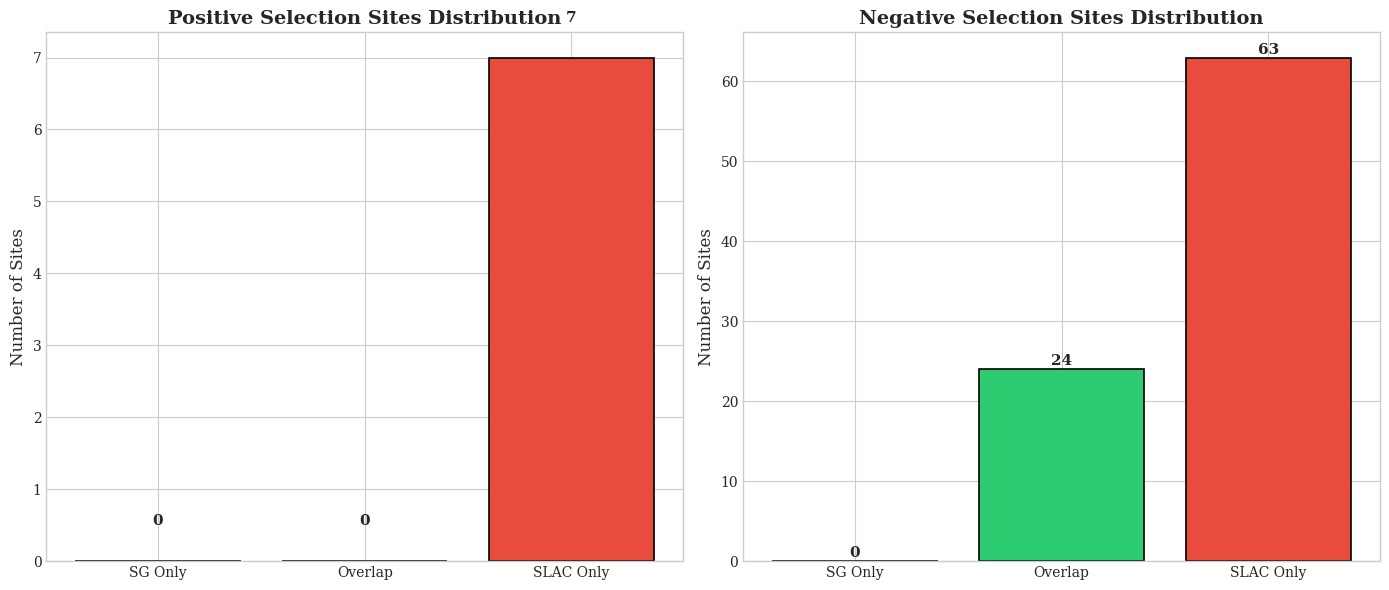

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

categories = ["SG Only", "Overlap", "SLAC Only"]
pos_values = [len(pos_sg_only), len(pos_overlap), len(pos_slac_only)]
neg_values = [len(neg_sg_only), len(neg_overlap), len(neg_slac_only)]
colors = ["#3498db", "#2ecc71", "#e74c3c"]

axes[0].bar(categories, pos_values, color=colors, edgecolor="black", linewidth=1.2)
axes[0].set_ylabel("Number of Sites", fontsize=12)
axes[0].set_title("Positive Selection Sites Distribution", fontsize=14, fontweight="bold")
for i, v in enumerate(pos_values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=11, fontweight="bold")

axes[1].bar(categories, neg_values, color=colors, edgecolor="black", linewidth=1.2)
axes[1].set_ylabel("Number of Sites", fontsize=12)
axes[1].set_title("Negative Selection Sites Distribution", fontsize=14, fontweight="bold")
for i, v in enumerate(neg_values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("out/bar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


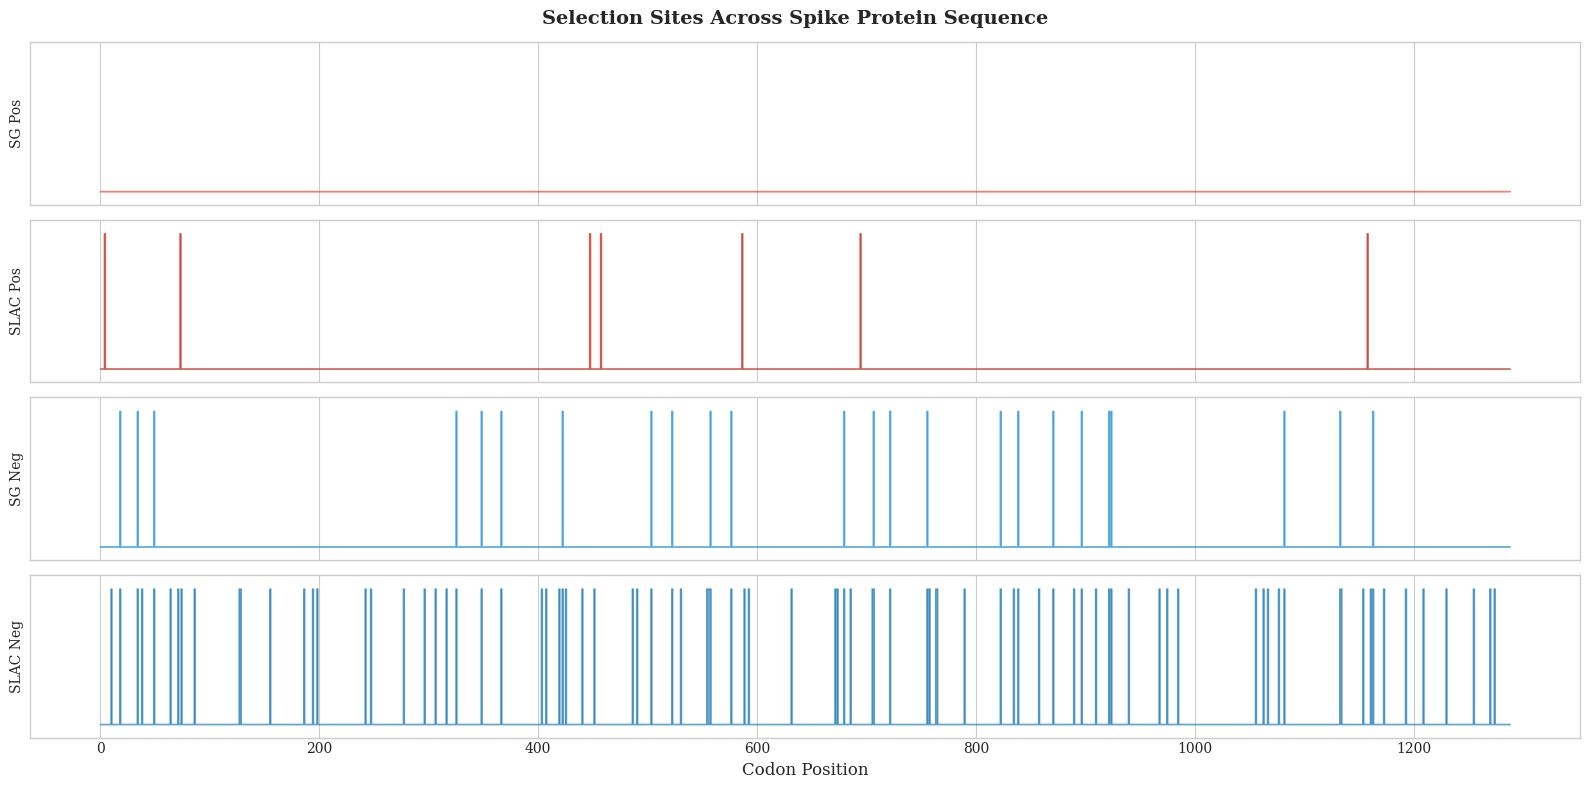

In [9]:
total_codons = sequence_length // 3
sg_pos_array = np.zeros(total_codons)
sg_neg_array = np.zeros(total_codons)
slac_pos_array = np.zeros(total_codons)
slac_neg_array = np.zeros(total_codons)

for pos in sg_pos_set:
    sg_pos_array[pos // 3] = 1
for pos in sg_neg_set:
    sg_neg_array[pos // 3] = 1
for pos in slac_pos_set:
    slac_pos_array[pos // 3] = 1
for pos in slac_neg_set:
    slac_neg_array[pos // 3] = 1

fig, axes = plt.subplots(4, 1, figsize=(16, 8), sharex=True)

axes[0].fill_between(range(total_codons), sg_pos_array, step="mid", alpha=0.7, color="#e74c3c")
axes[0].set_ylabel("SG Pos", fontsize=10)
axes[0].set_ylim(-0.1, 1.1)
axes[0].set_yticks([])

axes[1].fill_between(range(total_codons), slac_pos_array, step="mid", alpha=0.7, color="#c0392b")
axes[1].set_ylabel("SLAC Pos", fontsize=10)
axes[1].set_ylim(-0.1, 1.1)
axes[1].set_yticks([])

axes[2].fill_between(range(total_codons), sg_neg_array, step="mid", alpha=0.7, color="#3498db")
axes[2].set_ylabel("SG Neg", fontsize=10)
axes[2].set_ylim(-0.1, 1.1)
axes[2].set_yticks([])

axes[3].fill_between(range(total_codons), slac_neg_array, step="mid", alpha=0.7, color="#2980b9")
axes[3].set_ylabel("SLAC Neg", fontsize=10)
axes[3].set_ylim(-0.1, 1.1)
axes[3].set_yticks([])
axes[3].set_xlabel("Codon Position", fontsize=12)

fig.suptitle("Selection Sites Across Spike Protein Sequence", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("out/genome_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
print("=" * 80)
print("DETAILED COMPARISON SUMMARY")
print("=" * 80)

print("\n--- POSITIVE SELECTION ---")
print(f"Overlapping sites (both methods agree): {sorted([p//3 + 1 for p in pos_overlap])}")
print(f"SG-only sites: {sorted([p//3 + 1 for p in pos_sg_only])}")
print(f"SLAC-only sites: {sorted([p//3 + 1 for p in pos_slac_only])}")

print("\n--- NEGATIVE SELECTION ---")
print(f"Overlapping sites (both methods agree): {sorted([p//3 + 1 for p in neg_overlap])}")
print(f"SG-only sites: {sorted([p//3 + 1 for p in neg_sg_only])}")
print(f"SLAC-only sites: {sorted([p//3 + 1 for p in neg_slac_only])}")


DETAILED COMPARISON SUMMARY

--- POSITIVE SELECTION ---
Overlapping sites (both methods agree): []
SG-only sites: []
SLAC-only sites: [5, 74, 448, 458, 587, 695, 1158]

--- NEGATIVE SELECTION ---
Overlapping sites (both methods agree): [19, 35, 50, 326, 349, 367, 423, 504, 523, 558, 577, 680, 707, 722, 756, 823, 839, 871, 897, 922, 924, 1082, 1133, 1163]
SG-only sites: []
SLAC-only sites: [11, 39, 65, 72, 75, 87, 128, 129, 156, 187, 195, 199, 243, 248, 278, 297, 307, 317, 404, 408, 420, 426, 441, 452, 487, 491, 531, 555, 556, 557, 589, 593, 632, 672, 674, 686, 706, 758, 764, 765, 790, 835, 858, 890, 910, 940, 968, 975, 985, 1056, 1063, 1067, 1077, 1134, 1154, 1161, 1173, 1193, 1209, 1230, 1255, 1270, 1274]


In [11]:
print("=" * 80)
print("QUANTIFIABLE METRICS SUMMARY")
print("=" * 80)

total_sg = len(sg_pos_set) + len(sg_neg_set)
total_slac = len(slac_pos_set) + len(slac_neg_set)
total_overlap = len(pos_overlap) + len(neg_overlap)
total_sg_only = len(pos_sg_only) + len(neg_sg_only)
total_slac_only = len(pos_slac_only) + len(neg_slac_only)

all_sg = sg_pos_set | sg_neg_set
all_slac = slac_pos_set | slac_neg_set

print(f"\nTotal sites detected:")
print(f"  SG Method: {total_sg}")
print(f"  SLAC Method: {total_slac}")
if total_slac != total_sg:
    print(f"  SLAC finds {total_slac - total_sg:+d} more sites than SG")
else:
    print("  Both methods find equal number of sites")

print(f"\nAgreement metrics:")
print(f"  Sites found by both methods: {total_overlap}")
print(f"  Sites found only by SG: {total_sg_only}")
print(f"  Sites found only by SLAC: {total_slac_only}")

overall_jaccard = jaccard_similarity(all_sg, all_slac)
overall_overlap = overlap_coefficient(all_sg, all_slac)
sg_recovery = len(all_sg & all_slac) / len(all_sg) if len(all_sg) > 0 else 0

print(f"\nSimilarity scores:")
print(f"  Overall Jaccard Similarity: {overall_jaccard:.4f}")
print(f"  Overall Overlap Coefficient: {overall_overlap:.4f}")
print(f"  SG Recovery Rate (% of SG sites also found by SLAC): {sg_recovery*100:.1f}%")


QUANTIFIABLE METRICS SUMMARY

Total sites detected:
  SG Method: 24
  SLAC Method: 94
  SLAC finds +70 more sites than SG

Agreement metrics:
  Sites found by both methods: 24
  Sites found only by SG: 0
  Sites found only by SLAC: 70

Similarity scores:
  Overall Jaccard Similarity: 0.2553
  Overall Overlap Coefficient: 1.0000
  SG Recovery Rate (% of SG sites also found by SLAC): 100.0%


In [12]:
if len(slac_positive) > 0:
    slac_pos_df = pd.DataFrame(slac_positive)
    slac_pos_df["in_sg"] = slac_pos_df["position"].isin(sg_pos_set)
    print("SLAC Positive Selection Sites:")
    print(slac_pos_df[["codon_pos", "dN_dS", "p_value", "s_c", "n_c", "in_sg"]].to_string(index=False))

if len(slac_negative) > 0:
    slac_neg_df = pd.DataFrame(slac_negative)
    slac_neg_df["in_sg"] = slac_neg_df["position"].isin(sg_neg_set)
    print("\nSLAC Negative Selection Sites:")
    print(slac_neg_df[["codon_pos", "dN_dS", "p_value", "s_c", "n_c", "in_sg"]].to_string(index=False))


SLAC Positive Selection Sites:
 codon_pos        dN_dS  p_value  s_c  n_c  in_sg
         5 3.977998e+08 0.011417    0    8  False
        74 2.500000e+08 0.044050    0    5  False
       448 3.133384e+08 0.044050    0    5  False
       458 4.036752e+08 0.023313    0    7  False
       587 4.187209e+08 0.014293    0    9  False
       695 3.488908e+08 0.017635    0    7  False
      1158 2.498106e+08 0.044412    0    5  False

SLAC Negative Selection Sites:
 codon_pos        dN_dS      p_value  s_c  n_c  in_sg
        11 5.000000e-09 3.605611e-02    2    0  False
        19 2.376397e-02 4.531615e-10   21    1   True
        35 4.166659e-02 2.820286e-03    3    1   True
        39 3.333333e-09 3.605611e-02    1    0  False
        50 1.666685e-09 3.030692e-03    2    0   True
        65 3.333333e-09 3.605611e-02    1    0  False
        72 3.333333e-09 3.605611e-02    1    0  False
        75 3.333333e-09 1.417426e-02    2    0  False
        87 3.329366e-09 3.605611e-02    1    0  Fal